In [1]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [2]:
#Function 1
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 1.csv') 
columns = ['Input 1', 'Input 2', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
#Add Week 7's data to our pandas dataframe
new_data7 = np.array([0.329743, 0.09222, -4.8263877948748134e-82])
data.loc[len(data)] = new_data7
data





,Input 1,Input 2,Outputs
0,0.319404,0.762959,1.320000e-79
1,0.574329,0.879898,1.030000e-46
2,0.731024,0.733000,7.710000e-16
3,0.840353,0.264732,3.340000e-124
4,0.650114,0.681526,-3.610000e-03
5,0.410437,0.147554,-2.160000e-54
6,0.312691,0.078723,-2.090000e-91
7,0.683418,0.861057,2.540000e-40
8,0.082507,0.403488,3.610000e-81
9,0.883890,0.582254,6.230000e-48


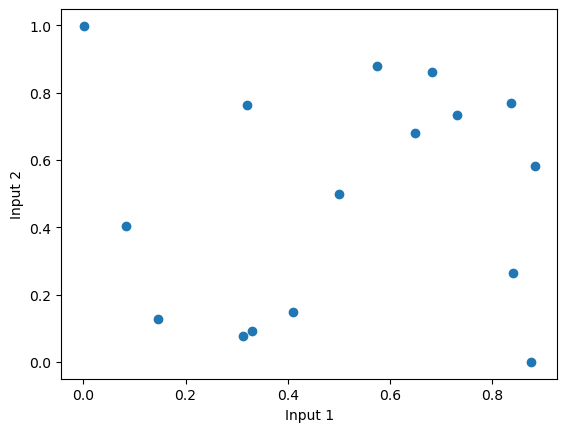

In [3]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])
#Visualise already explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [4]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Outputs
Input 1,1.000000,0.059594,-0.126685
Input 2,0.059594,1.000000,-0.150511
Outputs,-0.126685,-0.150511,1.000000


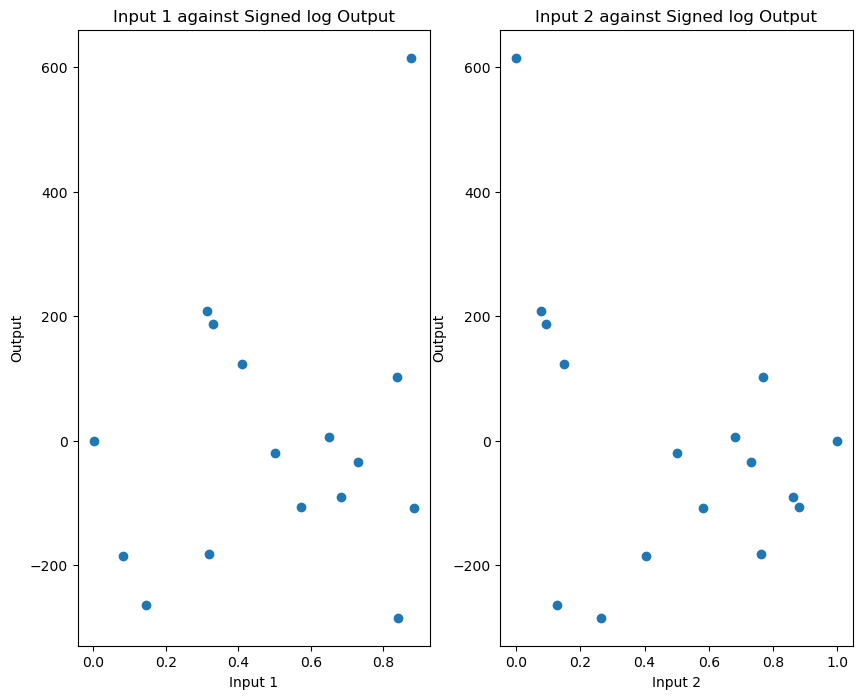

In [5]:
#Plotting each Input against the signed log of the output
#Plotting the log of the (absolute value) output since the values are very small
fig, ax = plt.subplots(1,2, figsize = (10,8))
ax[0].scatter(X[:,0], np.sign(Y)*np.log(np.abs(Y)+1e-300))
ax[1].scatter(X[:,1], np.sign(Y)*np.log(np.abs(Y)+1e-300))

#Creating titles and axis labels
ax[0].set_title('Input 1 against Signed log Output')
ax[1].set_title('Input 2 against Signed log Output')

ax[0].set_xlabel('Input 1')
ax[0].set_ylabel('Output')

ax[1].set_xlabel('Input 2')
ax[1].set_ylabel('Output')
plt.show()

In [6]:
#We now use random forest regression to generate a list of promising points for a GP
#to evaluate
from sklearn.ensemble import RandomForestRegressor
#Using randomized search CV for light hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [0.5, 0.7, 1.0]
}

rf = RandomForestRegressor(
    n_jobs=-1,
    random_state=42
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1, random_state = 42)

search.fit(X, Y.ravel())

rf_best = search.best_estimator_
print("Tuned RF Model:", rf_best)


Tuned RF Model: RandomForestRegressor(max_depth=20, max_features=0.7, min_samples_leaf=5,
                      n_estimators=300, n_jobs=-1, random_state=42)


In [7]:
#Use Latin hypercube sampling to initialise candidate points
d = 2
n = 10000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Use random forest model to outputs from the grid
Y_pred = rf_best.predict(grid)

#Select the top 200 points
n_select = 200
top_idx = np.argsort(Y_pred)[-n_select:]
X_candidates = grid[top_idx]

In [10]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp.fit(X,Y)

#fit GP to candidate points generated by Random Forest model
mu, std = gp.predict(X_candidates, return_std = True)
 
#fit GP to candidate points generated over entire domain for comparison 
mu_grid, std_grid = gp.predict(grid, return_std = True)

In [13]:
#Calculate UCB
beta = 1.96 #set exploration parameter
UCB = mu + beta*std
UCB_grid = mu_grid + beta*std_grid 
#Find point selected by random forest model that maximizes UCB 
X_next = X_candidates[np.argmax(UCB)]
#Find point in the entire domain that maximizes UCB
X_next_grid = grid[np.argmax(UCB_grid)]
print("Random Forest Hybrid model next suggested point:", np.round(X_next,6))
print("Pure GP model next suggested point:", np.round(X_next_grid,6))

Random Forest Hybrid model next suggested point: [0.251298 0.141955]
Pure GP model next suggested point: [0.760497 0.793517]
